## Notebook to create a colormap for matplotlib duplicating the colormap used to make the plots in GSiFeF2.pdf

In [1]:
from PIL import Image
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
Image.open('GSiFeF2_colorbar.png')

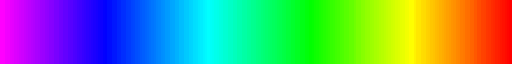

In [3]:
colors = (
    pd.DataFrame(np.array(Image.open('GSiFeF2_colorbar.png'))[::-1, 8, :])
    .drop_duplicates()
    .iloc[1:-2]
    .div(255)
    .to_numpy()
)
geotail_cmap = ListedColormap(colors, name="geotail_cmap", )
geotail_cmap.set_under([1., 1., 1.])
geotail_cmap.set_over([0, 0, 0])
geotail_cmap

In [6]:
with open('geotail_cmap.py', 'w') as cmap_file:
    cmap_file.write('from matplotlib.colors import ListedColormap\nimport numpy as np\n\n')
    cmap_file.write('def make_geotail_cmap():\n    geotail_cmap = ListedColormap( [np.array(color) / 255 for color in [\n')
    cmap_file.write(
        pd.DataFrame(np.array(Image.open('GSiFeF2_colorbar.png'))[::-1, 8, :])
        .drop_duplicates()
        .iloc[1:-2]
        .astype(str)
        .apply(lambda s_: f"({s_[0]}, {s_[1]}, {s_[2]}), ", axis='columns')
        .to_string(index=False)
    )
    cmap_file.write(']\n], name="geotail_cmap", )\n')
    cmap_file.write('    geotail_cmap.set_under([1., 1., 1.])\n')
    cmap_file.write('    geotail_cmap.set_over([0, 0, 0])\n')
    cmap_file.write('    return geotail_cmap\n\n')
    cmap_file.write('geotail_cmap = make_geotail_cmap()\n')


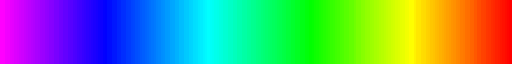

In [8]:
from geotail_cmap import geotail_cmap as gcm
gcm